In [ ]:
# various import statements
import os
import inspect
import seaborn
import matplotlib
import matplotlib.pyplot as plt
import torch
import scanpy as sc
import pyro
import copy

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import sys
import antipode
from antipode.antipode_model import *
import antipode.model_functions
from antipode.model_functions import *
import antipode.model_distributions
from antipode.model_distributions import *
import antipode.model_modules
from antipode.model_modules import *
import antipode.train_utils
from antipode.train_utils import *
import antipode.plotting
from antipode.plotting import *

In [ ]:
def fest(tensors,unsqueeze=0,scalar=1.,epsilon=1e-10):
    '''
    flexible_einsum_scale_tensor, first dimension must be equal for list of tensors
    Multiplies out marginals to construct joint
    '''
    einsum_str = ','.join(f'...z{chr(65 + i)}' for i, _ in enumerate(tensors))
    einsum_str += '->...' + ''.join(chr(65 + i) for i, _ in enumerate(tensors))
    out=torch.einsum(einsum_str, *[x/(x.sum(-1,keepdim=True)) for x in tensors])[*indexing_none_list(unsqueeze)]
    return [poutine.scale(scale=scalar*out+epsilon)]


class ANTIPODE(PyroBaseModuleClass,AntipodeTrainingMixin, AntipodeSaveLoadMixin):
    """
    ANTIPODE (Single Cell Ancestral Node Taxonomy Inference by Parcellation of Differential Expression) 
    leverages variational inference for analyzing and categorizing cell types by accounting for biological and batch covariates and discrete and continuous latent variables. This model works by simultaneously integrating evolution-inspired differential expression parcellation, taxonomy generation (clustering) and batch correction.

    Parameters:
    adata (AnnData): The single-cell dataset encapsulated in an AnnData object.
    discov_pair (tuple): Specifies the discovery covariate's key and its location ('obs' or 'obsm') in the AnnData object.
    batch_pair (tuple): Specifies the batch covariate's key and its location ('obs' or 'obsm') in the AnnData object.
    seccov_key (string):  Specifies the secondary covariate matrix's key in obsm in the AnnData object. Only affects DM.
    layer (str): The specific layer of the AnnData object to be analyzed.
    level_sizes (list of int): Defines the hierarchical model structure (corresponding to a layered tree) by specifying the size of each level. Make sure each layer gets progressively larger and ideally start with a single root. Defaults to [1, 10, 100].
    bi_depth (int): Tree depth (from root) for batch identity effect correction. Defaults to 2. Should be less than length of level_sizes
    psi_levels (list of bool): Whether or not to allow a psi at each level of the layered tree. Should be 1. (all levels) or a list of len(level_sizes)
    
    num_latent (int): The number of latent dimensions to model. Defaults to 50.
    num_batch_embed (int): Number of embedding dimensions for batch effects. Defaults to 10. 
    scale_factor (float, optional): Factor for scaling the data normalization. Inferred from data if None. [DANGER]
    prior_scale (float): Scale for the Laplace prior distributions. Defaults to 100. [DANGER]
    dcd_prior (float, optional): Scale for discov_constitutive_de. Use this for missing genes (set to large negative value and rest 0. Zeros if None.
    use_psi (bool): Whether to utilize psi continuous variation parameter. Defaults to True.
    use_q_score (bool): Whether to use q continuous "quality" scores. Defaults to True.
    dist_normalize (bool): EXPERIMENTAL. Whether to apply distance normalization. Defaults to False.
    z_transform (pytorch function): Function to be applied to latent space (Z) e.g. centered_sigmoid, sigmoid. This will mess up DE Parameter scaling.
    loc_as_param, zdw_as_param, intercept_as_param (bool): Flags for using location, Z decoder weight, and intercept as parameters instead (maximum likelihood inference instead of Laplace MAP), respectively. All default to False.
    theta_prior (float): Initial value for the inverse dispersion of the negative binomial. Defaults to 50. [DANGER]
    scale_init_val (float): Initial value for scaling parameters in phase 1. Defaults to 0.01. [DANGER]
    classifier_hidden, encoder_hidden, batch_embedder_hidden (list of int): Sizes of hidden layers for the classifier, encoder and batch embedding networks, respectively.
    sampler_category (string): Obs categorical column which will be used with the dataloader to sample each category with equal probability. (suggested use is the discov category)
    """

    def __init__(self, adata, discov_pair, batch_pair, layer, seccov_key='seccov_dummy', level_sizes=[1,10,100],
                 num_latent=50,scale_factor=None, prior_scale=100,dcd_prior=None,use_psi=True,sampler_category=None,
                 loc_as_param=True,zdw_as_param=True,intercept_as_param=True,seccov_as_param=True,use_q_score=True,psi_levels=[True],
                 num_batch_embed=10,theta_prior=50.,min_theta=1.,scale_init_val=0.01,bi_depth=2,dist_normalize=False,z_transform=None,
                 classifier_hidden=[3000,3000,3000],encoder_hidden=[6000,5000,3000,1000],batch_embedder_hidden=[1000,500,500]):

        pyro.clear_param_store()
        self.init_args = dict(locals())
        # Determine num_discov and num_batch from the AnnData object
        self.discov_loc, self.discov_key = discov_pair
        self.batch_loc, self.batch_key = batch_pair
        self.seccov_key=seccov_key
        self.num_discov = adata.obsm[self.discov_key].shape[-1] if self.discov_loc == 'obsm' else len(adata.obs[self.discov_key].unique())
        self.num_batch = adata.obsm[self.batch_key].shape[-1] if self.batch_loc == 'obsm' else len(adata.obs[self.batch_key].unique())        
        self.design_matrix = (self.discov_loc == 'obsm')
        self.layer = layer
        self.num_seccov = adata.obsm[self.seccov_key].shape[-1] if self.seccov_key != 'seccov_dummy' else 1
        
        self._setup_adata_manager_store: dict[str, type[scvi.data.AnnDataManager]] = {}
        self.num_var = adata.layers[layer].shape[-1]
        self.num_latent = num_latent
        self.scale_factor = 1.0#scale_factor if scale_factor is not None else 2e2 / (self.num_var * num_particles * num_latent)
        self.num_batch_embed = num_batch_embed
        self.temperature = 0.1
        self.epsilon = 1e-5
        self.approx = False
        self.prior_scale = prior_scale
        self.use_psi = use_psi
        self.use_q_score = use_q_score
        self.loc_as_param = loc_as_param
        self.zdw_as_param = zdw_as_param
        self.seccov_as_param = seccov_as_param
        self.intercept_as_param = intercept_as_param
        self.theta_prior = theta_prior
        self.scale_init_val = scale_init_val
        self.level_sizes = level_sizes
        self.num_labels = sum(level_sizes)
        self.bi_depth = bi_depth
        self.bi_depth = sum(self.level_sizes[:self.bi_depth])
        self.dist_normalize = dist_normalize
        self.sampler_category = sampler_category
        self.psi_levels = [float(x) for x in psi_levels]
        self.min_theta=min_theta

        self.dcd_prior = torch.zeros((self.num_discov,self.num_var)) if dcd_prior is None else dcd_prior#Use this for 
                
        # Initialize plates to be used during sampling
        self.var_plate = pyro.plate('var_plate',self.num_var,dim=-1)
        self.discov_plate = pyro.plate('discov_plate',self.num_discov,dim=-3)
        self.seccov_plate = pyro.plate('seccov_plate',self.num_seccov,dim=-3)
        self.batch_plate = pyro.plate('batch_plate',self.num_batch,dim=-3)
        self.latent_plate = pyro.plate('latent_plate',self.num_latent,dim=-1)
        self.latent_plate2 = pyro.plate('latent_plate2',self.num_latent,dim=-2)
        self.label_plate = pyro.plate('label_plate',self.num_labels,dim=-2)
        self.batch_embed_plate = pyro.plate('batch_embed_plate',self.num_batch_embed,dim=-3)
        self.bi_depth_plate = pyro.plate('bi_depth_plate',self.bi_depth,dim=-2)

        #Initialize MAP inference modules
        self.dm=MAPLaplaceModule(self,'discov_dm',[self.num_discov,self.num_labels,self.num_latent],[self.discov_plate,self.label_plate,self.latent_plate],param_only=True)
        self.sm=MAPLaplaceModule(self,'seccov_dm',[self.num_seccov,self.num_labels,self.num_latent],[self.seccov_plate,self.label_plate,self.latent_plate],param_only=self.seccov_as_param)
        self.bm=MAPLaplaceModule(self,'batch_dm',[self.num_batch,self.num_labels,self.num_latent],[self.batch_plate,self.label_plate,self.latent_plate],param_only=True)
        self.di=MAPLaplaceModule(self,'discov_di',[self.num_discov,self.num_labels,self.num_var],[self.discov_plate,self.label_plate,self.var_plate],param_only=True)
        self.bei=MAPLaplaceModule(self,'batch_di',[self.num_batch_embed,self.bi_depth,self.num_var],[self.batch_embed_plate,self.bi_depth_plate,self.var_plate],param_only=True)
        self.ci=MAPLaplaceModule(self,'cluster_intercept',[self.num_labels, self.num_var],[self.label_plate,self.var_plate],param_only=self.intercept_as_param)
        self.dc=MAPLaplaceModule(self,'discov_dc',[self.num_discov,self.num_latent,self.num_var],[self.discov_plate,self.latent_plate2,self.var_plate],param_only=True)
        self.zdw=MAPLaplaceModule(self,'z_decoder_weight',[self.num_latent,self.num_var],[self.latent_plate2,self.var_plate],init_val=((2/self.num_latent)*(torch.rand(self.num_latent,self.num_var)-0.5)),param_only=self.zdw_as_param)
        self.zl=MAPLaplaceModule(self,'locs',[self.num_labels,self.num_latent],[self.label_plate,self.latent_plate],param_only=self.loc_as_param)
        self.zs=MAPHalfCauchyModule(self,'scales',[self.num_labels,self.num_latent],[self.label_plate,self.latent_plate],init_val=self.scale_init_val*torch.ones(self.num_labels,self.num_latent),constraint=constraints.positive,param_only=False)
        self.zld=MAPLaplaceModule(self,'locs_dynam',[self.num_labels,self.num_latent],[self.label_plate,self.latent_plate],param_only=False)
        self.qg=MAPLaplaceModule(self,'quality_genes',[1,self.num_var],[self.var_plate],param_only=False)
        
        self.tree_edges = TreeEdges(self,straight_through=False)
        self.tree_convergence_bottom_up = TreeConvergenceBottomUp(self,strictness=1/self.num_labels)        
        self.z_transform = null_function if z_transform is None else z_transform#centered_sigmoid#torch.special.expit

        if self.design_matrix:
            fields={'s':('layers',self.layer),
            'discov_ind':('obsm',self.discov_key),
            'batch_ind':('obsm',self.batch_key),
            'seccov':('obsm',self.seccov_key)}
            field_types={"s":np.float32,"batch_ind":np.float32,"discov_ind":np.float32,'seccov':np.float32}
        else:
            fields={'s':('layers',self.layer),
            'discov_ind':('obs',self.discov_key),
            'batch_ind':('obs',self.batch_key),
            'seccov':('obsm',self.seccov_key)}
            field_types={"s":np.float32,"batch_ind":np.int64,"discov_ind":np.int64,'seccov':np.float32}

        self.fields=fields
        self.field_types=field_types
        self.setup_anndata(adata, {'discov_ind': discov_pair, 'batch_ind': batch_pair,'seccov':self.seccov_key}, self.field_types)
        
        super().__init__()
        # Setup the various neural networks used in the model and guide
        self.z_decoder=ZDecoder(num_latent=self.num_latent, num_var=self.num_var)        
        self.zl_encoder=ZLEncoder(num_var=self.num_var,hidden_dims=encoder_hidden,num_cat_input=self.num_discov,
                    outputs=[(self.num_latent,None),(self.num_latent,softplus),(1,None),(1,softplus)])
        
        self.classifier=Classifier(num_latent=self.num_latent,hidden_dims=classifier_hidden,
                    outputs=[(self.num_labels,None),(len(self.level_sizes),None),(len(self.level_sizes),softplus)])

        #Too large to exactly model gene-level batch effects for all cluster x batch
        self.be_nn=SimpleFFNN(in_dim=self.num_batch,hidden_dims=batch_embedder_hidden,
                    out_dim=self.num_batch_embed)
        
        self.epsilon = 0.006
        #Initialize model not in fuzzy mode
        self.approx=False
        self.prior_scale=prior_scale
        self.args=inspect.getfullargspec(self.model).args[1:]#skip self

    def setup_anndata(self,adata: anndata.AnnData,fields,field_types,**kwargs,):
        if self.seccov_key == 'seccov_dummy':
            adata.obsm['seccov_dummy']=np.zeros([adata.shape[0],1],dtype=np.int8)
        anndata_fields=[make_field(x,self.fields[x]) for x in self.fields.keys()]
            
        adata_manager = scvi.data.AnnDataManager(
            fields=anndata_fields
        )
        adata_manager.register_fields(adata, **kwargs)
        self.register_manager(adata_manager)
        if fields['discov_ind'][0]=='obsm':
            self.design_matrix=True
            if fields['batch_ind'][0]!='obsm':
                raise Exception("If discov is design matrix, batch must be as well!")

    def register_manager(self, adata_manager: scvi.data.AnnDataManager):
        adata_id = adata_manager.adata_uuid
        self._setup_adata_manager_store[adata_id] = adata_manager
        self.adata_manager=adata_manager
    
    def set_approx(self,b: bool):
        self.approx=b

    def set_freeze_encoder(self,b: bool):
        self.freeze_encoder=b

    # the generative model
    def model(self, s,discov_ind=torch.zeros(1),batch_ind=torch.zeros(1),seccov=torch.zeros(1),step=torch.ones(1),taxon=torch.zeros(1),Z_obs=torch.zeros(1)):
        # Register various nn.Modules (i.e. the decoder/encoder networks) with Pyro
        pyro.module("antipode", self)

        if not self.design_matrix:
            batch=index_to_onehot(batch_ind,[s.shape[0],self.num_batch]).to(s.device)
            discov=index_to_onehot(discov_ind,[s.shape[0],self.num_discov]).to(s.device)
            batch_ind=batch_ind.squeeze()
            discov_ind=discov_ind.squeeze()
        else:
            batch=batch_ind
            discov=discov_ind
        
        minibatch_plate=pyro.plate("minibatch_plate", s.shape[0],dim=-1)
        minibatch_plate2=pyro.plate("minibatch_plate2", s.shape[0],dim=-2)
        l = s.sum(1).unsqueeze(-1)
        
        # Scale all sample statements for numerical stability
        with poutine.scale(scale=self.scale_factor):
            # Counts parameter of NB (variance of the observation distribution)
            s_theta = pyro.param("s_inverse_dispersion", self.theta_prior * s.new_ones(self.num_var),
                               constraint=constraints.positive)
            
            #Weak overall histogram normalization
            discov_mul = pyro.param("discov_mul", s.new_ones(self.num_discov,1),constraint=constraints.positive) if self.dist_normalize else s.new_ones(self.num_discov,1)
            cur_discov_mul = torch.einsum('do,bd->bo',discov_mul, discov_ind) if self.design_matrix else discov_mul[discov_ind]

            dcd=pyro.param("discov_constitutive_de", self.dcd_prior.to(s.device))
            with poutine.scale(scale=1/self.num_labels):
                level_edges=self.tree_edges.model_sample(s,approx=self.approx)
            quality_genes=self.qg.model_sample(s) if self.use_q_score else 0.
            print(Z_obs)
            with minibatch_plate:
                batch_embed=centered_sigmoid(pyro.sample('batch_embed', dist.Laplace(s.new_zeros(self.num_batch_embed),
                                self.prior_scale*s.new_ones(self.num_batch_embed),validate_args=True).to_event(1)))
                beta_prior_a=1.*s.new_ones(self.num_labels)
                beta_prior_a[0]=10. #0 block is consititutive
                if self.approx:#Bernoulli blocks approx?
                    taxon_probs = pyro.sample("taxon_probs", dist.Beta(beta_prior_a,s.new_ones(self.num_labels),validate_args=True).to_event(1))
                    with poutine.scale(scale=1/self.num_labels):
                        taxon = pyro.sample('taxon',dist.RelaxedBernoulli(temperature=0.1*s.new_ones(1),probs=taxon_probs).to_event(1))
                else:
                    taxon_probs=pyro.sample('taxon_probs',dist.Dirichlet(s.new_ones(s.shape[0],self.level_sizes[-1]),validate_args=True))
                    if sum(taxon.shape) > 1:#Supervised?
                        if taxon.shape[-1]==self.num_labels:#Totally supervised?
                            pass
                        else:#Only bottom layer is supervised?
                            #taxon = taxon_probs = pyro.sample("taxon", dist.OneHotCategorical(probs=taxon_probs,validate_args=True),obs=taxon)
                            with poutine.scale(scale=1/self.num_labels):
                                taxon = taxon_probs = pyro.sample("taxon", dist.OneHotCategorical(probs=s.new_ones([s.shape[0],self.num_labels]),validate_args=True),obs=taxon)
                            taxon = self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s)
                            taxon = torch.concat(taxon,-1)
                    else:#Unsupervised
                        with poutine.scale(scale=1/self.num_labels):
                            taxon = pyro.sample("taxon", 
                                             model_distributions.SafeAndRelaxedOneHotCategorical(temperature=self.temperature*s.new_ones(1),probs=taxon_probs,validate_args=True))                    
                        #print(taxon)
                        taxon = self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s)
                        #print(taxon[0].shape)
                        print([p.shape for p in taxon])
                        taxon = torch.concat(taxon,-1)
                    
                    taxon_probs=self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s)
                    taxon_probs=torch.cat(taxon_probs,-1)
                   
            locs=self.zl.model_sample(s,scale=fest([taxon_probs],-1))
            scales=self.zs.model_sample(s,scale=fest([taxon_probs],-1))
            locs_dynam=self.zld.model_sample(s,scale=fest([taxon_probs],-1))
            discov_dm=self.dm.model_sample(s,scale=fest([discov,taxon_probs],-1))
            seccov_dm=self.sm.model_sample(s,scale=fest([seccov.abs()+1e-9,taxon_probs],-1))
            discov_di=self.di.model_sample(s,scale=fest([discov,taxon_probs],-1))
            batch_dm=self.bm.model_sample(s,scale=fest([batch,taxon_probs],-1))
            
            bei=self.bei.model_sample(s,scale=fest([batch_embed.abs(),taxon_probs[...,:self.bi_depth]],-1))
            cluster_intercept=self.ci.model_sample(s,scale=fest([taxon_probs],-1))
            
            with minibatch_plate:
                bi=torch.einsum('...bi,...ijk->...bjk',batch_embed,bei)
                bi=torch.einsum('...bj,...bjk->...bk',taxon[...,:self.bi_depth],bi)
                psi = centered_sigmoid(pyro.sample('psi',dist.Laplace(s.new_zeros(s.shape[0],len(self.level_sizes)),self.prior_scale*s.new_ones(s.shape[0],len(self.level_sizes))).to_event(1)))
                psi=psi*torch.tensor(self.psi_levels).to(s.device).unsqueeze(0)
                psi = 0 if not self.use_psi or self.approx else torch.repeat_interleave(psi, torch.tensor(self.level_sizes).to(s.device), dim=1)
                q = torch.sigmoid(pyro.sample('q',dist.Logistic(s.new_zeros(s.shape[0],1),s.new_ones(s.shape[0],1)).to_event(1))) if self.use_q_score else 1.0
                this_locs=oh_index(locs,taxon)
                this_scales=oh_index(scales,taxon)
                z=pyro.sample('z_loc',dist.Laplace(this_locs,0.5*self.prior_scale*s.new_ones(s.shape[0],self.num_latent),validate_args=True).to_event(1))
                z_dist=dist.Normal(this_locs,this_scales+self.epsilon,validate_args=True).to_event(1)
                if sum(Z_obs.shape) <=1: 
                     z=pyro.sample('z', z_dist) 
                else: #Supervised latent space
                    z=pyro.sample('z', z_dist)
                    z=pyro.sample('z_obs', dist.Normal(z,this_scales+self.epsilon,validate_args=True).to_event(1),obs=Z_obs)

            cur_discov_dm = oh_index1(discov_dm, discov_ind) if self.design_matrix else discov_dm[discov_ind]
            cur_batch_dm = oh_index1(batch_dm, batch_ind) if self.design_matrix else batch_dm[batch_ind]
            cur_dcd = oh_index(dcd, discov) if self.design_matrix else  dcd[discov_ind]
            cur_seccov_dm=oh_index1(seccov_dm,seccov)
            # fake_di=pyro.sample('fake_di_sample',dist.Laplace(s.new_zeros(s.shape[0],self.num_var),self.prior_scale*s.new_ones(s.shape[0],self.num_var)).to_event(2))
            # fake_di=pyro.sample('fake_nb_sample',dist.NegativeBinomial(5*s.new_ones(s.shape[0],self.num_var),0.1*s.new_ones(s.shape[0],self.num_var)).to_event(2))
            
            z=z+oh_index2(cur_discov_dm,taxon) + oh_index2(cur_seccov_dm,taxon) + oh_index2(cur_batch_dm,taxon)+(oh_index(locs_dynam,taxon*psi))
            z=self.z_transform(z)                
            pseudo_z=oh_index(locs,taxon_probs)+oh_index2(cur_discov_dm,taxon_probs)+ oh_index2(cur_seccov_dm,taxon_probs) + oh_index2(cur_batch_dm,taxon_probs)+(oh_index(locs_dynam,taxon_probs*psi))
            pseudo_z=self.z_transform(pseudo_z)
            z_decoder_weight=self.zdw.model_sample(s,scale=fest([pseudo_z.abs()],-1))
            discov_dc=self.dc.model_sample(s,scale=fest([discov,pseudo_z.abs()],-1))
            cur_discov_di = oh_index1(discov_di, discov_ind) if self.design_matrix else discov_di[discov_ind]
            cur_discov_dc = oh_index1(discov_dc, discov_ind) if self.design_matrix else discov_dc[discov_ind]
            cur_discov_di=oh_index2(cur_discov_di,taxon)
            cur_cluster_intercept=oh_index(cluster_intercept,taxon) if not self.approx else 0.
            
            mu=torch.einsum('...bi,...bij->...bj',z,z_decoder_weight+cur_discov_dc)#+bc
            spliced_mu=mu+cur_dcd+cur_discov_di+cur_cluster_intercept+bi+((1-q)*quality_genes)
            norm_spliced_mu=spliced_mu*cur_discov_mul
            spliced_out=softmax(norm_spliced_mu,dim=-1)
            log_mu = (l * spliced_out + 1e-6).log()
            s_theta = (s_theta * q) + self.min_theta
            fake_di=pyro.sample('fake_nb_obs_outplate_sample',dist.NegativeBinomial(5*s.new_ones(s.shape[0],self.num_var),0.1*s.new_ones(s.shape[0],self.num_var)).to_event(2),obs=s.new_zeros(s.shape[0],self.num_var))
            with self.var_plate,minibatch_plate2:
                s_dist = dist.NegativeBinomial(total_count=s_theta + 0.1,logits=log_mu-s_theta.log(),validate_args=False)
                print('theta',s_theta)
                print(log_mu-s_theta.log())
                print(s)
                s_out=pyro.sample("s", s_dist, obs=s.int())
                #s_out=pyro.sample("s_guess0", s_dist, obs=s.new_zeros(s.shape[0],self.num_var))
                #fake_di=pyro.sample('fake_nb_obs_inplate_sample',dist.NegativeBinomial(5*s.new_ones(s.shape[0],self.num_var),0.1*s.new_ones(s.shape[0],self.num_var)),obs=s.new_zeros(s.shape[0],self.num_var))
                # s_dist = dist.Normal((log_mu-s_theta.log()).exp(),1/s_theta + 0.1)
                # s_out=pyro.sample("s_normal", s_dist, obs=s)
            
            return(norm_spliced_mu)

    
    # the variational distribution
    def guide(self, s,discov_ind=torch.zeros(1),batch_ind=torch.zeros(1),seccov=torch.zeros(1),step=torch.ones(1),taxon=torch.zeros(1),Z_obs=torch.zeros(1)):
        pyro.module("antipode", self)
        
        if not self.design_matrix:
            batch=index_to_onehot(batch_ind,[s.shape[0],self.num_batch]).to(s.device)
            discov=index_to_onehot(discov_ind,[s.shape[0],self.num_discov]).to(s.device)
            batch_ind=batch_ind.squeeze()
            discov_ind=discov_ind.squeeze()
        else:
            batch=batch_ind
            discov=discov_ind
        
        minibatch_plate=pyro.plate("minibatch_plate", s.shape[0])
        print(s.shape)
        with poutine.scale(scale=self.scale_factor):
            with poutine.scale(scale=1/self.num_labels):
                level_edges=self.tree_edges.guide_sample(s,approx=self.approx) 
            with minibatch_plate:
                batch_embed=self.be_nn(batch)
                batch_embed=centered_sigmoid(pyro.sample('batch_embed', dist.Delta(batch_embed,validate_args=True).to_event(1)))
                if self.freeze_encoder:
                    with torch.no_grad():
                        z_loc, z_scale , q_loc,q_scale= self.zl_encoder(s,discov)
                        z_loc=z_loc.detach()
                        z_scale=z_scale.detach()
                        q_loc=q_loc.detach()
                        q_scale=q_scale.detach()
                else:
                    z_loc, z_scale, q_loc,q_scale= self.zl_encoder(s,discov)
                fake_di=pyro.param('fake_di',s.new_zeros(self.num_discov,self.num_labels,self.num_var))
                fake_di_scale=pyro.param('fake_di_scale',s.new_ones(self.num_discov,self.num_labels,self.num_var))
                fake_s=pyro.param('fake_s',s.new_zeros(self.num_discov,self.num_labels,self.num_var))
                z=pyro.sample('z',dist.Normal(z_loc,z_scale+self.epsilon).to_event(1))
                q=pyro.sample('q',dist.Normal(q_loc,q_scale+self.epsilon).to_event(1))
                pyro.sample('z_loc',dist.Delta(z_loc).to_event(1))
                z=self.z_transform(z)
                taxon_logits,psi_loc,psi_scale=self.classifier(z)
                psi=centered_sigmoid(pyro.sample('psi',dist.Normal(psi_loc,psi_scale+self.epsilon).to_event(1)))
                psi=psi*torch.tensor(self.psi_levels).to(s.device).unsqueeze(0)
                psi = 0 if not self.use_psi or self.approx else torch.repeat_interleave(psi, torch.tensor(self.level_sizes).to(s.device), dim=1)
                if self.approx:
                    taxon_dist = dist.Delta(safe_sigmoid(taxon_logits),validate_args=True).to_event(1)
                    taxon_probs = pyro.sample("taxon_probs", taxon_dist)
                    with poutine.scale(scale=1/self.num_labels):
                        taxon = pyro.sample('taxon',dist.RelaxedBernoulli(temperature=self.temperature*s.new_ones(1),probs=taxon_probs).to_event(1))
                else:
                    taxon_probs=pyro.sample('taxon_probs',dist.Delta(safe_softmax(taxon_logits[...,-self.level_sizes[-1]:],eps=1e-5)).to_event(1))
                    if sum(taxon.shape) > 1:
                        pass
                    else:
                        with poutine.scale(scale=1/self.num_labels):
                            taxon = pyro.sample("taxon", 
                                             model_distributions.SafeAndRelaxedOneHotCategorical(temperature=self.temperature*s.new_ones(1),probs=taxon_probs,validate_args=True))                    
                    if taxon.shape[-1]<self.num_labels:
                        taxon = self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s)
                        taxon = torch.concat(taxon,-1)
                    #print('taxon probs',taxon_probs.shape)
                    taxon_probs=self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s)
                    #print('taxon probs',taxon_probs)
                    taxon_probs=torch.cat(taxon_probs,-1)

            # fake_di=pyro.sample('fake_di_sample_aux',dist.Normal(fake_di[discov_ind,taxon.argmax(-1),:],fake_di_scale[discov_ind,taxon.argmax(-1),:]).to_event(2),infer={'auxiliary':True})
            # fake_di=pyro.sample('fake_di_sample',dist.Delta(fake_di).to_event(2))
            #fake_nb=pyro.sample('fake_nb_sample',dist.Delta(fake_s[discov_ind,taxon.argmax(-1),:]).to_event(2))
            #fake_di=pyro.sample('fake_di_sample',dist.Delta(fake_di[discov_ind,taxon.argmax(-1),:]).to_event(2))
            quality_genes=self.qg.guide_sample(s) if self.use_q_score else 0.
            locs=self.zl.guide_sample(s,scale=fest([taxon_probs],-1))
            scales=self.zs.guide_sample(s,scale=fest([taxon_probs],-1))
            locs_dynam=self.zld.guide_sample(s,scale=fest([taxon_probs],-1))
            discov_dm=self.dm.guide_sample(s,scale=fest([discov,taxon_probs],-1))
            seccov_dm=self.sm.guide_sample(s,scale=fest([seccov.abs()+1e-9,taxon_probs],-1))
            batch_dm=self.bm.guide_sample(s,scale=fest([batch,taxon_probs],-1))
            discov_di=self.di.guide_sample(s,scale=fest([discov,taxon_probs],-1))
            cluster_intercept=self.ci.guide_sample(s,scale=fest([taxon_probs],-1))
            bei=self.bei.guide_sample(s,scale=fest([batch_embed.abs(),taxon_probs[...,:self.bi_depth]],-1))#maybe should be abs sum bei
            cur_discov_dm = oh_index1(discov_dm, discov_ind) if self.design_matrix else discov_dm[discov_ind]
            cur_batch_dm = oh_index1(batch_dm, batch_ind) if self.design_matrix else batch_dm[batch_ind]
            cur_seccov_dm=oh_index1(seccov_dm,seccov)
            
            z=oh_index(locs,taxon)+oh_index2(cur_discov_dm,taxon)+oh_index2(cur_seccov_dm,taxon) + oh_index2(cur_batch_dm,taxon)+(oh_index(locs_dynam,taxon*psi))
            z=self.z_transform(z)
            pseudo_z=oh_index(locs,taxon_probs)+oh_index2(cur_discov_dm,taxon_probs)+oh_index2(cur_seccov_dm,taxon_probs) + oh_index2(cur_batch_dm,taxon_probs)+(oh_index(locs_dynam,taxon_probs*psi))
            pseudo_z=self.z_transform(pseudo_z)
            z_decoder_weight=self.zdw.guide_sample(s,scale=fest([pseudo_z.abs()],-1))
            discov_dc=self.dc.guide_sample(s,scale=fest([discov,pseudo_z.abs()],-1))


In [ ]:
batch_key='batch_name'
discov_key='species'
layer_key='spliced'

In [ ]:
batch_size=32
steps=0
max_steps=100000
num_particles=1
print_every=5000

# Clear Pyro param store so we don't conflict with previous run
try:
    pyro.clear_param_store()
    del antipode_model
    torch.cuda.empty_cache()
except:
    pass
# Fix random number seed to a lucky number
pyro.util.set_rng_seed(13)
# Enable optional validation warnings
pyro.enable_validation(False)

model_tag='1.9.1.8.3_Dev-Free-DMR'
# Instantiate instance of model/guide and various neural networks

antipode_model=ANTIPODE.load(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),prefix='p3_',device=device)
adata=antipode_model.adata_manager.adata
#antipode_model=ANTIPODE.load(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),adata=adata,prefix='p3_',device=device)


In [179]:
#antipode_model.prepare_phase_2(cluster='kmeans',epochs=None)

In [180]:
antipode_model.prior_scale=1.0

In [187]:
antipode_model.train()
antipode_model.train_phase(phase=3,max_steps=max_steps,print_every=10000,num_particles=1,device=device, max_learning_rate=1e-3, one_cycle_lr=True, steps=0, batch_size=batch_size,print_elbo=False)

  0%|          | 1/100000 [00:00<4:29:13,  6.19it/s]

fix scale factor
torch.Size([32, 16738])
tensor([0.])
[torch.Size([32, 1]), torch.Size([32, 50]), torch.Size([32, 200])]
theta tensor([[ 5.2435,  5.0055,  5.2513,  ...,  5.9381,  7.3511,  5.2735],
        [ 8.1621,  5.0709,  8.2636,  ..., 17.1828, 35.5319,  8.5519],
        [ 7.6820,  5.0601,  7.7681,  ..., 15.3329, 30.8958,  8.0126],
        ...,
        [ 8.9720,  5.0891,  9.0995,  ..., 20.3030, 43.3514,  9.4616],
        [ 8.0490,  5.0684,  8.1469,  ..., 16.7471, 34.4398,  8.4249],
        [ 8.9298,  5.0881,  9.0560,  ..., 20.1406, 42.9444,  9.4142]],
       device='cuda:0')
tensor([[ -3.3629,  -2.0460,  -4.3257,  ...,  -5.9042, -10.2226, -10.5851],
        [ -2.2945,  -1.0121,  -2.7232,  ...,  -5.8111, -12.1423, -10.4259],
        [ -2.2711,  -0.7936,  -3.3757,  ...,  -5.9502, -12.3891,  -8.9420],
        ...,
        [ -4.3437,  -5.9521,  -3.0564,  ...,  -7.7742, -15.8037, -12.3962],
        [ -5.5473,  -5.0473,  -4.0636,  ...,  -8.0050, -13.9048, -11.5727],
        [ -5.9308,  -3

/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/antipode/train_utils.py:282: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if sum(index.shape) == 1:
/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/antipode/train_utils.py:285: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  index=torch.nn.functional.one_hot(index.squeeze(),num_classes=out_shape[1]).float() if index.shape[-1]==1 else index
/scratch/fast/17290428/ipykernel_328327/2202113128.py:352: TracerWarning: torch.tensor re

tensor([0.])
[torch.Size([32, 1]), torch.Size([32, 50]), torch.Size([32, 200])]
theta tensor([[ 5.4941,  5.0111,  5.5100,  ...,  6.9037,  9.7710,  5.5550],
        [ 7.1321,  5.0478,  7.2006,  ..., 13.2145, 25.5867,  7.3949],
        [ 5.7854,  5.0176,  5.8106,  ...,  8.0259, 12.5833,  5.8822],
        ...,
        [ 8.2660,  5.0732,  8.3708,  ..., 17.5830, 36.5348,  8.6686],
        [ 5.6167,  5.0138,  5.6365,  ...,  7.3761, 10.9549,  5.6928],
        [ 6.7329,  5.0389,  6.7885,  ..., 11.6763, 21.7317,  6.9465]],
       device='cuda:0', grad_fn=<AddBackward0>)
tensor([[ -3.3817,  -2.5265,  -4.8702,  ...,  -7.2330, -11.4692,  -9.1293],
        [ -2.2669,  -0.8602,  -2.7131,  ...,  -5.7102, -11.1346, -10.9824],
        [ -1.8980,  -0.7371,  -2.8558,  ...,  -5.1429, -11.2848,  -8.5208],
        ...,
        [ -4.3504,  -5.8906,  -3.0681,  ...,  -7.5768, -15.8324, -13.3677],
        [ -5.3045,  -4.6498,  -3.8191,  ...,  -7.2898, -12.6488, -11.2161],
        [ -5.7008,  -3.8858,  -5.3678, 

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/pyro/distributions/torch_patch.py:74: TracerWarning: torch.as_tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  value = torch.as_tensor(
  2%|▏         | 2002/100000 [01:44<1:24:14, 19.39it/s]

fix scale factor
torch.Size([32, 16738])
tensor([0.])
[torch.Size([32, 1]), torch.Size([32, 50]), torch.Size([32, 200])]
theta tensor([[ 5.0259,  5.0006,  5.0268,  ...,  5.0999,  5.2507,  5.0292],
        [ 5.6800,  5.0152,  5.7022,  ...,  7.6192, 11.5701,  5.7640],
        [ 5.6354,  5.0142,  5.6561,  ...,  7.4474, 11.1392,  5.7139],
        ...,
        [ 6.0087,  5.0226,  6.0416,  ...,  8.8852, 14.7459,  6.1333],
        [ 5.7885,  5.0177,  5.8141,  ...,  8.0369, 12.6179,  5.8859],
        [ 5.3000,  5.0067,  5.3098,  ...,  6.1555,  7.8985,  5.3371]],
       device='cuda:0')
tensor([[ -3.7097,  -3.6476,  -4.3232,  ...,  -3.5211, -12.8900,  -9.2226],
        [ -3.7115,  -3.5429,  -5.5525,  ...,  -7.8290, -10.9198,  -9.8970],
        [ -3.5124,  -3.1440,  -4.9384,  ...,  -7.0875, -10.5597, -10.0707],
        ...,
        [ -3.4858,  -3.4079,  -3.2140,  ...,  -4.9381, -10.2049,  -5.6134],
        [ -3.9180,  -3.9215,  -3.3836,  ...,  -5.5270,  -9.3812,  -5.8850],
        [ -4.0074,  -3

  3%|▎         | 3199/100000 [02:39<1:13:52, 21.84it/s]
KeyboardInterrupt



# Training Phase 3: Refining the final tree

In [205]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

Thu Jun 13 18:09:44 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  | 00000000:66:00.0 Off |                    0 |
| N/A   30C    P0              37W / 250W |   1577MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Thu Jun 13 18:09:45 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  | 00000000:66:00.0 Off |                    0 |
| N/A   30C    P0              48W / 250W |   1577MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [206]:
plot_loss(antipode_model.losses)

AttributeError: 'ANTIPODE' object has no attribute 'losses'

In [207]:
antipode_model.store_outputs(device=device,prefix='')

In [208]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Thu Jun 13 18:10:37 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  | 00000000:66:00.0 Off |                    0 |
| N/A   36C    P0              40W / 250W |   1625MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [209]:
plot_loss(antipode_model.losses)
plot_gmm_heatmaps(antipode_model)
plot_d_hists(antipode_model)
plot_batch_embedding_pca(antipode_model)

AttributeError: 'ANTIPODE' object has no attribute 'losses'

In [210]:
aggr_means=antipode.model_functions.group_aggr_anndata(adata,['species','level_2'],layer='norm_spliced')
log_real_means=np.log(aggr_means[0]+1e-3) # #species,#cluster,#genes array

100%|██████████| 588/588 [00:24<00:00, 24.26it/s]


In [211]:
real_means=pd.DataFrame(log_real_means.mean(0),columns=adata.var.index,index=aggr_means[1]['level_2'])
real_means=real_means.loc[aggr_means[1]['level_2'],:]

In [212]:
real_dev_mouse_means=pd.DataFrame(log_real_means[2],columns=adata.var.index,index=aggr_means[1]['level_2'])
real_dev_mouse_means=real_dev_mouse_means.loc[aggr_means[1]['level_2'],:]

In [213]:
prefix=''
pstore=adata.uns['param_store']
n_clusters=antipode_model.level_sizes[-1]
level_edges=[antipode.model_functions.numpy_hardmax(antipode_model.adata_manager.adata.uns[prefix+'param_store']['edges_'+str(i)],axis=-1) for i in range(len(antipode_model.level_sizes)-1)]
levels=antipode_model.tree_convergence_bottom_up.just_propagate(np.eye(antipode_model.level_sizes[-1]),level_edges)
prop_taxon=np.concatenate(levels,axis=-1)

discov_labels=adata.obs[antipode_model.discov_key].cat.categories
latent_labels=[str(x) for x in range(pstore['discov_dc'].shape[1])]
adata.obs['level_2']=adata.obs['level_2'].astype('category')
cluster_index=adata.obs['level_2'].cat.categories.astype(int)#list(range(antipode_model.level_sizes[-1]))#list(range(pstore['locs'].shape[0]))
cluster_labels=list(adata.obs['level_2'].cat.categories)
cluster_label_dict=dict(zip(cluster_index,cluster_labels))
var_labels=adata.var.index

prop_locs=prop_taxon@pstore['locs']
prop_cluster_intercept=prop_taxon@pstore['cluster_intercept']
cluster_params=(prop_locs@pstore['z_decoder_weight'])+prop_cluster_intercept+np.mean(pstore['discov_constitutive_de'],0,keepdims=True)
cluster_params=cluster_params[cluster_index,:]

#Need to propagate multilayer tree to discovs
prop_discov_di = np.einsum('pc,dcg->dpg',prop_taxon,pstore['discov_di'])
prop_discov_dm = np.einsum('pc,dcm->dpm',prop_taxon,pstore['discov_dm'])
discov_cluster_params=np.einsum('dpm,dmg->dpg',prop_locs+prop_discov_dm,pstore['z_decoder_weight']+pstore['discov_dc'])+(prop_cluster_intercept+prop_discov_di+np.expand_dims(pstore['discov_constitutive_de'],1))
discov_cluster_params=discov_cluster_params

In [214]:
dev_cons_means=pd.DataFrame(cluster_params,columns=adata.var.index,index=cluster_labels)
dev_cons_means=dev_cons_means.loc[aggr_means[1]['level_2'],:]

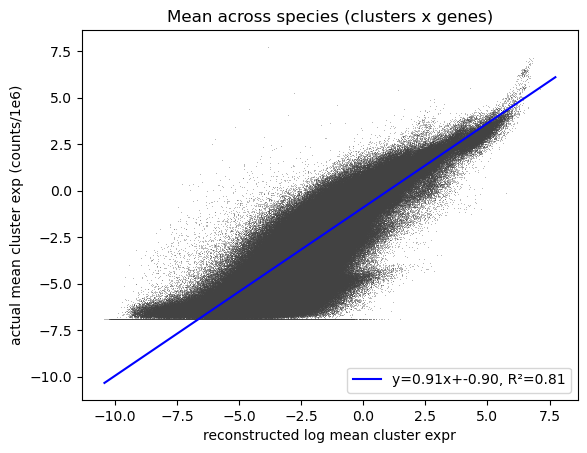

In [215]:
randinds=np.random.choice(np.array(list(range(log_real_means.mean(0).flatten().shape[0]))),size=10000,replace=False)
x=dev_cons_means.to_numpy().flatten()
y=real_means.to_numpy().flatten()
seaborn.scatterplot(x=x,y=y,s=0.2,color='black')
#seaborn.kdeplot(x=x[randinds],y=y[randinds],linestyles='--',color='red', linewidths=0.5)
plt.xlabel('reconstructed log mean cluster expr')
plt.ylabel('actual mean cluster exp (counts/1e6)')

# Calculate the regression parameters
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x,y)

# Plot the regression line
x_values = np.linspace(np.min(x), np.max(y), 100)
plt.plot(x_values, slope * x_values + intercept, color='blue', label=f'y={slope:.2f}x+{intercept:.2f}, R²={r_value**2:.2f}')
plt.title('Mean across species (clusters x genes)')
# Add legend
plt.legend()
plt.show()

In [216]:
fits=[]
for g in tqdm.tqdm(dev_cons_means.columns):
    x=dev_cons_means.loc[:,g]
    y=real_means.loc[:,g]
    fits.append(scipy.stats.stats.pearsonr(x,y).statistic)


  0%|          | 0/16738 [00:00<?, ?it/s]/scratch/fast/17290428/ipykernel_328327/1220075513.py:5: DeprecationWarning: Please use `pearsonr` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  fits.append(scipy.stats.stats.pearsonr(x,y).statistic)
 22%|██▏       | 3673/16738 [00:03<00:10, 1213.81it/s]/home/matthew.schmitz/.local/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
100%|██████████| 16738/16738 [00:14<00:00, 1164.67it/s]


0.5013031590502224


Text(0.5, 1.0, '')

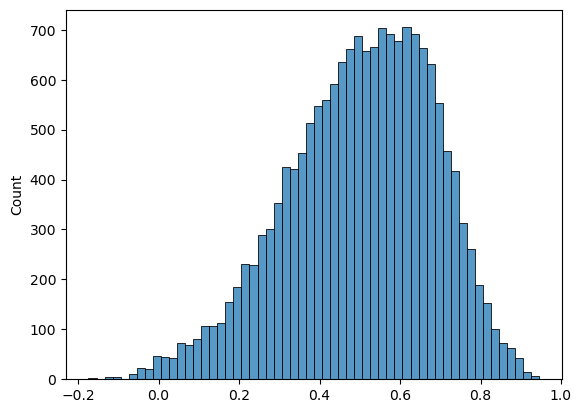

In [217]:
print(np.mean(np.nan_to_num(fits)))
seaborn.histplot(fits)
plt.title('')

0.49943350766640693


Text(0.5, 1.0, '')

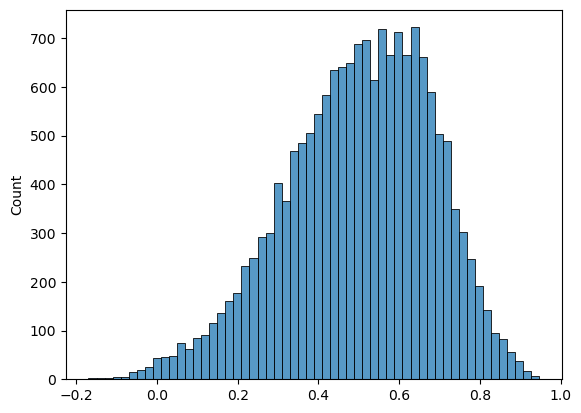

In [201]:
print(np.mean(np.nan_to_num(fits)))
seaborn.histplot(fits)
plt.title('')

In [220]:
device='cuda'
# antipode_model.adata_manager.register_new_fields([scvi.data.fields.ObsmField('Z_obs','X_antipode')])
# antipode_model.adata_manager.register_new_fields([scvi.data.fields.ObsmField('taxon','taxon_probs')])
# supervised_field_types=copy.deepcopy(antipode_model.field_types)
# supervised_field_types["taxon"]=np.float32
# supervised_field_types["Z_obs"]=np.float32

dataloader=scvi.dataloaders.AnnDataLoader(antipode_model.adata_manager,batch_size=32,drop_last=False,shuffle=False,data_and_attributes=antipode_model.field_types)#supervised_field_types for supervised step 

outs=[]
antipode_model.to(device)
antipode_model.eval()
with torch.no_grad():
    for x in tqdm.tqdm(dataloader):
        x=dict(zip(x.keys(),[x[k].to(device) for k in x.keys()]))
        #out=antipode_model.model(**x)
        out=pyro.infer.predictive.Predictive(antipode_model.model,guide=antipode_model.guide,num_samples=1)(**x)
        print(out)
        outs.append(out.cpu().detach().numpy())
        


  0%|          | 0/15430 [00:00<?, ?it/s]


torch.Size([32, 16738])
torch.Size([32, 16738])
torch.Size([32, 16738])
[torch.Size([32, 1]), torch.Size([32, 50]), torch.Size([32, 200])]
[torch.Size([32, 1]), torch.Size([32, 50]), torch.Size([32, 200])]
[torch.Size([1, 1, 1, 32, 1]), torch.Size([1, 1, 1, 32, 50]), torch.Size([1, 1, 32, 200])]


RuntimeError: Tensors must have same number of dimensions: got 5 and 4
                     Trace Shapes:                       
                      Param Sites:                       
 antipode$$$zl_encoder.fc.0.weight      6000 16742       
 antipode$$$zl_encoder.fc.2.weight            6000       
   antipode$$$zl_encoder.fc.2.bias            6000       
 antipode$$$zl_encoder.fc.4.weight      5000  6000       
 antipode$$$zl_encoder.fc.6.weight            5000       
   antipode$$$zl_encoder.fc.6.bias            5000       
 antipode$$$zl_encoder.fc.8.weight      3000  5000       
antipode$$$zl_encoder.fc.10.weight            3000       
  antipode$$$zl_encoder.fc.10.bias            3000       
antipode$$$zl_encoder.fc.12.weight      1000  3000       
antipode$$$zl_encoder.fc.14.weight            1000       
  antipode$$$zl_encoder.fc.14.bias            1000       
antipode$$$zl_encoder.fc.16.weight       302  1000       
antipode$$$zl_encoder.fc.18.weight             302       
 

In [157]:
pred=pyro.infer.predictive.Predictive(antipode_model.model,guide=antipode_model.guide,num_samples=1)

In [160]:
pred(**x)

torch.Size([251, 1]) tensor(1024.)
torch.Size([251, 1]) tensor(1024.)
torch.Size([251, 1]) tensor(1024.)
torch.Size([3, 251, 1]) tensor(1024.0007)
torch.Size([1, 251, 1]) tensor(1024.)
torch.Size([407, 251, 1]) tensor(1024.)
torch.Size([3, 251, 1]) tensor(1024.0007)
torch.Size([251, 1]) tensor(1024.)
torch.Size([10, 51, 1]) tensor(1024.0002)
torch.Size([150, 1]) tensor(1023.9999)
torch.Size([3, 150, 1]) tensor(1024.)
torch.Size([251, 1]) tensor(1024.)
torch.Size([251, 1]) tensor(1024.)
torch.Size([251, 1]) tensor(1024.)
torch.Size([3, 251, 1]) tensor(1024.0007)
torch.Size([1, 251, 1]) tensor(1024.)
torch.Size([407, 251, 1]) tensor(1024.0001)
torch.Size([3, 251, 1]) tensor(1024.0007)
torch.Size([251, 1]) tensor(1024.)
torch.Size([10, 51, 1]) tensor(1024.0002)
torch.Size([150, 1]) tensor(1024.)
torch.Size([3, 150, 1]) tensor(1024.)
torch.Size([251, 1]) tensor(1024.)
torch.Size([251, 1]) tensor(1024.)
torch.Size([251, 1]) tensor(1024.)
torch.Size([3, 251, 1]) tensor(1024.0007)
torch.Size(

RuntimeError: Tensors must have same number of dimensions: got 5 and 4
                     Trace Shapes:                       
                      Param Sites:                       
 antipode$$$zl_encoder.fc.0.weight      6000 16742       
 antipode$$$zl_encoder.fc.2.weight            6000       
   antipode$$$zl_encoder.fc.2.bias            6000       
 antipode$$$zl_encoder.fc.4.weight      5000  6000       
 antipode$$$zl_encoder.fc.6.weight            5000       
   antipode$$$zl_encoder.fc.6.bias            5000       
 antipode$$$zl_encoder.fc.8.weight      3000  5000       
antipode$$$zl_encoder.fc.10.weight            3000       
  antipode$$$zl_encoder.fc.10.bias            3000       
antipode$$$zl_encoder.fc.12.weight      1000  3000       
antipode$$$zl_encoder.fc.14.weight            1000       
  antipode$$$zl_encoder.fc.14.bias            1000       
antipode$$$zl_encoder.fc.16.weight       302  1000       
antipode$$$zl_encoder.fc.18.weight             302       
 

In [ ]:
adata.layers['reconstructed']=np.concatenate(outs,axis=0)

In [199]:
aggr_reconst_means=antipode.model_functions.group_aggr_anndata(adata,['species','level_2'],layer='reconstructed')


  0%|          | 0/588 [00:00<?, ?it/s]


KeyError: 'reconstructed'

In [ ]:
reconst_means=pd.DataFrame(aggr_reconst_means[0].mean(0),columns=adata.var.index,index=aggr_reconst_means[1]['level_2'])
reconst_means=reconst_means.loc[aggr_reconst_means[1]['level_2'],:]

In [ ]:
fits=[]
for g in tqdm.tqdm(dev_cons_means.columns):
    x=reconst_means.loc[:,g]
    y=real_means.loc[:,g]
    print(x,y)
    fits.append(scipy.stats.stats.pearsonr(x,y).statistic)


In [ ]:
print(np.mean(np.nan_to_num(fits)))
seaborn.histplot(fits)
plt.title('')

In [234]:
antipode_model.freeze_encoder=True
antipode_model.use_psi=False
antipode_model.use_q_score=False

In [237]:
device='cuda'
antipode_model.adata_manager.register_new_fields([scvi.data.fields.ObsmField('Z_obs','X_antipode')])
antipode_model.adata_manager.register_new_fields([scvi.data.fields.ObsmField('taxon','taxon_probs')])
supervised_field_types=copy.deepcopy(antipode_model.field_types)
supervised_field_types["taxon"]=np.float32
supervised_field_types["Z_obs"]=np.float32

dataloader=scvi.dataloaders.AnnDataLoader(antipode_model.adata_manager,batch_size=32,drop_last=False,shuffle=False,data_and_attributes=supervised_field_types)#supervised_field_types for supervised step 


scheduler=pyro.optim.OneCycleLR({
    'max_lr': 0.000000001,
    'total_steps': 1e9,
    'div_factor': 100,
    'optim_args': {},
    'optimizer': torch.optim.Adam
})

svi=pyro.infer.SVI(antipode_model.model, antipode_model.guide, scheduler, pyro.infer.JitTrace_ELBO)

outs=[]
antipode_model.to(device)
antipode_model.eval()
with torch.no_grad():
    for x in tqdm.tqdm(dataloader):
        x=dict(zip(x.keys(),[x[k].to(device) for k in x.keys()]))
        #out=antipode_model.model(**x)
        # out=pyro.infer.predictive.Predictive(antipode_model.model,guide=antipode_model.guide,num_samples=1)(**x)
        out=svi._traces(**x)
        print(out)
        outs.append(out.cpu().detach().numpy())


INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        



  0%|          | 0/15430 [00:00<?, ?it/s]

<generator object SVI._traces at 0x7f103f6f3400>


AttributeError: 'generator' object has no attribute 'cpu'

In [ ]:
MDE_KEY = "X_antipode_MDE"
adata.obsm[MDE_KEY] = clip_latent_dimensions(scvi.model.utils.mde(adata.obsm['X_antipode'],init='random'),0.1)
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["antipode_cluster","kmeans"],legend_fontsize=6,legend_fontweight='normal',
    legend_loc='on data',palette=sc.pl.palettes.godsnot_102
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'level' in x],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=['q_score',discov_key,batch_key],palette=sc.pl.palettes.godsnot_102,cmap='coolwarm'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'psi' in x],
    cmap='coolwarm',
    legend_loc='on data'
)

In [ ]:
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["neighborhood","curated_class_label"],legend_fontsize=6,legend_fontweight='normal',
    legend_loc='on data',palette=sc.pl.palettes.godsnot_102
)


sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["region","phase"]
)

In [ ]:
#antipode_model.save(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),save_anndata=True,prefix='p3_')

In [ ]:
# del adata
# antipode_model=ANTIPODE.load(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),prefix='p3_')
# antipode_model.train()
# adata=antipode_model.adata_manager.adata

In [ ]:
seaborn.histplot(adata.obs['q_score'])

In [ ]:
gene_list=['RBFOX3','PDGFRA','AQP4','FOXJ1','AIF1','MOG','COL1A2','CD34','COL4A1','FOXG1',
           'DLX2','PROX1','SCGN','NKX2-1','NPY','FOXP1','FOXP2','PDYN','PENK','ISL1','FEV',
           'HMX3','TH','LMX1A','TFAP2A','TFAP2B','RSPO1','NKX3-1','IGF1','ITPR2','OTX2','HOXB3','PAX1','PAX2','PAX3','PAX5','PAX6','PAX7','PAX8']
gene_list=[x for x in gene_list if x in adata.var.index]
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=gene_list,cmap='Purples',
    palette=sc.pl.palettes.godsnot_102,legend_fontsize=6,
    legend_loc='on data',use_raw=False
)
